# Foundations of Machine Learning: Regression

This notebook covers the fundamental concepts of regression analysis, based on the course material from DA5400: Foundations of Machine Learning.

## 1. Introduction to Regression

Regression analysis is a set of statistical processes for estimating the relationships between a dependent variable (often called the 'outcome variable') and one or more independent variables (often called 'predictors', 'covariates', or 'features').

The dependent variables should be continuous numerical variables. Common applications include:
- Predicting house prices given size, location, and number of bedrooms
- Predicting blood pressure given age, weight, activity level, and diet
- Predicting product sales given advertising budget, price, and customer demographics
- Predicting material strain given force applied and material properties

## 2. Simple Linear Regression

Simple linear regression is a linear regression model with a single explanatory variable. It describes a relationship between two variables by fitting a linear equation to observed data.

A linear regression line has an equation of the form:
$$y = w_0 + w_1 x + \epsilon$$

where:
- **y** is the dependent variable
- **x** is the independent variable
- **w₀** is the intercept (bias term)
- **w₁** is the slope (weight)
- **ε** is the error term

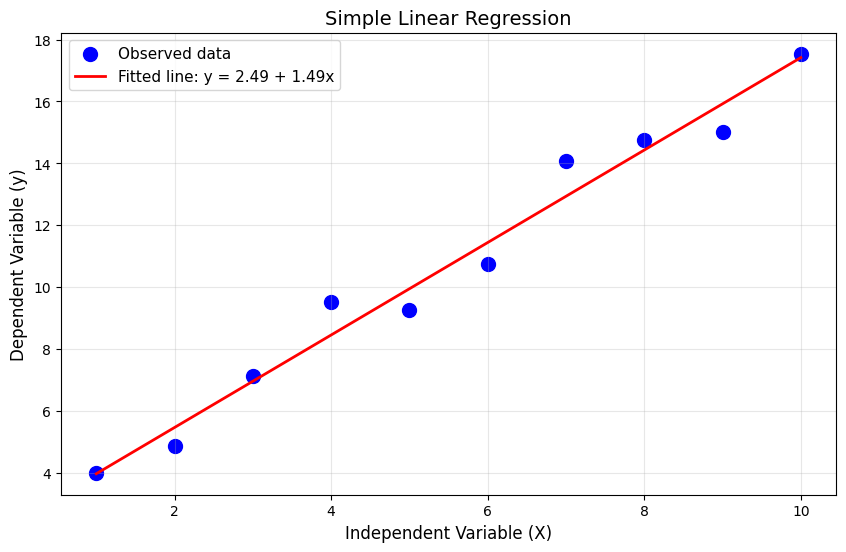

Intercept (w₀): 2.4860
Slope (w₁): 1.4931
R² Score: 0.9751


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate sample data for simple linear regression
np.random.seed(42)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = 2 + 1.5 * X.flatten() + np.random.normal(0, 1, 10)

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Get predictions
y_pred = model.predict(X)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Observed data', s=100)
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted line: y = {model.intercept_:.2f} + {model.coef_[0]:.2f}x')
plt.xlabel('Independent Variable (X)', fontsize=12)
plt.ylabel('Dependent Variable (y)', fontsize=12)
plt.title('Simple Linear Regression', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f'Intercept (w₀): {model.intercept_:.4f}')
print(f'Slope (w₁): {model.coef_[0]:.4f}')
print(f'R² Score: {model.score(X, y):.4f}')

## 3. Multiple Linear Regression

Multiple linear regression is an extension of simple linear regression. It is used when we want to predict the value of a variable based on the value of two or more other variables.

The general form is:
$$y = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + \epsilon$$

In matrix form:
$$\mathbf{y} = \mathbf{X}^* \mathbf{w} + \boldsymbol{\epsilon}$$

where **X*** includes the bias term (column of ones).

Intercept (w₀): 1.2316
Coefficients: w₁ = 1.9461, w₂ = 1.5441
Mean Squared Error: 0.1169
R² Score: 0.9953


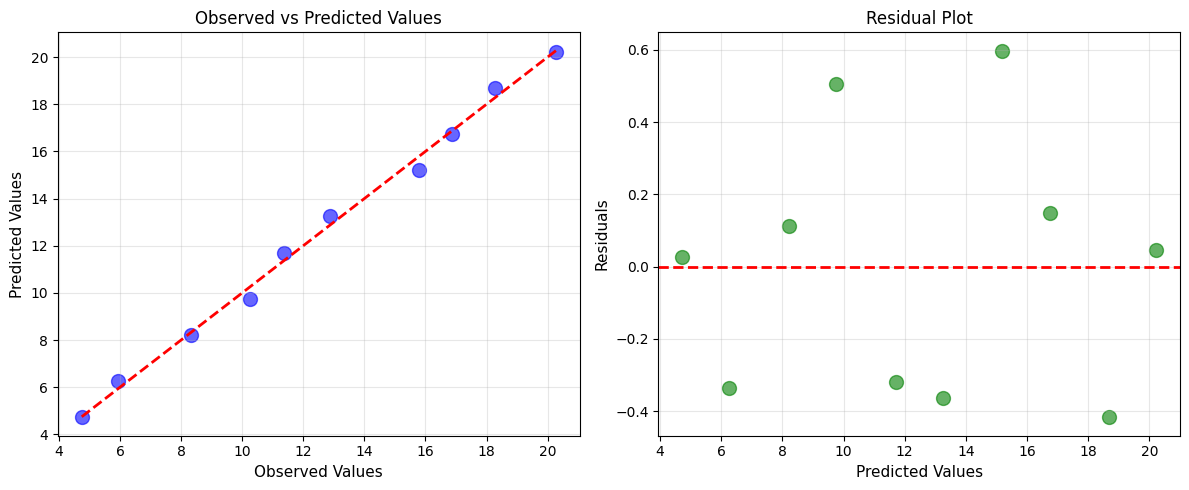

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample data with two independent variables
np.random.seed(42)
X_multi = np.array([
    [1, 1], [1, 2], [2, 2], [2, 3], [3, 3],
    [3, 4], [4, 4], [4, 5], [5, 5], [5, 6]
])
y_multi = 1 + 2*X_multi[:, 0] + 1.5*X_multi[:, 1] + np.random.normal(0, 0.5, 10)

# Create and fit the model
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Get predictions
y_pred_multi = model_multi.predict(X_multi)

# Calculate metrics
mse = mean_squared_error(y_multi, y_pred_multi)
r2 = r2_score(y_multi, y_pred_multi)

print(f'Intercept (w₀): {model_multi.intercept_:.4f}')
print(f'Coefficients: w₁ = {model_multi.coef_[0]:.4f}, w₂ = {model_multi.coef_[1]:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R² Score: {r2:.4f}')

# Visualization
fig = plt.figure(figsize=(12, 5))

# Plot 1: Observed vs Predicted
ax1 = fig.add_subplot(121)
ax1.scatter(y_multi, y_pred_multi, color='blue', s=100, alpha=0.6)
ax1.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 'r--', lw=2)
ax1.set_xlabel('Observed Values', fontsize=11)
ax1.set_ylabel('Predicted Values', fontsize=11)
ax1.set_title('Observed vs Predicted Values', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = fig.add_subplot(122)
residuals = y_multi - y_pred_multi
ax2.scatter(y_pred_multi, residuals, color='green', s=100, alpha=0.6)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Values', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.set_title('Residual Plot', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Ordinary Least Squares (OLS)

Ordinary Least Squares (OLS) is a method for estimating the unknown parameters in a linear regression model. OLS minimizes the sum of squared residuals (errors).

**Residual**: The difference between observed output and predicted output of a regression model.

**Sum of Squared Residuals (SSR)**:
$$SSR = (\mathbf{y} - \mathbf{X}^* \mathbf{w})^T (\mathbf{y} - \mathbf{X}^* \mathbf{w})$$

**OLS Estimate**: The coefficients that minimize SSR:
$$\hat{\mathbf{w}} = \arg\min_{\mathbf{w}} SSR$$

**Normal Equation** (Analytical Solution):
$$\hat{\mathbf{w}} = (\mathbf{X}^{*T} \mathbf{X}^*)^{-1} \mathbf{X}^{*T} \mathbf{y}$$

OLS Solution using Normal Equation:
Intercept (w₀): 3.1618
Slope (w₁): 1.2162

Sum of Squared Residuals: 24.5682
Mean Squared Error: 1.2284

Comparison with scikit-learn:
Intercept (sklearn): 3.1618
Slope (sklearn): 1.2162


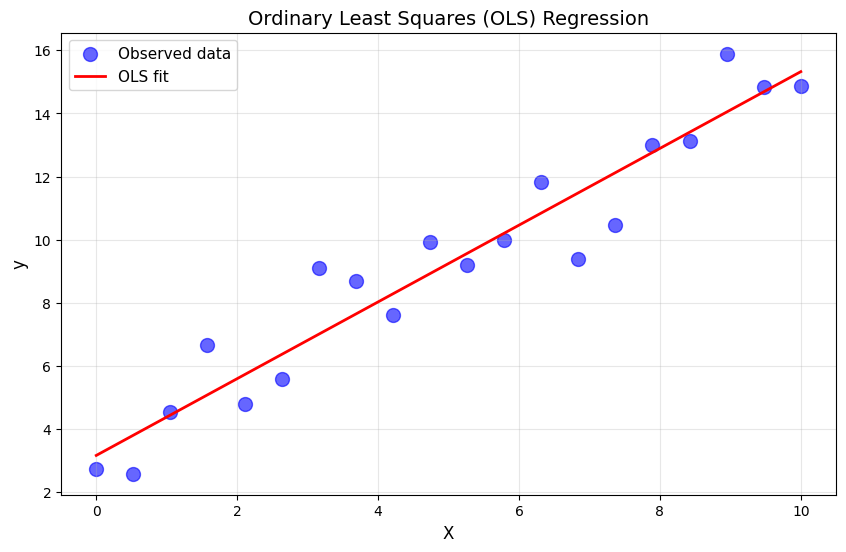

In [ ]:
# Implement OLS manually using the normal equation
import numpy as np
from numpy.linalg import inv

# Generate sample data
np.random.seed(42)
n_samples = 20
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y = 2 + 1.5 * X.flatten() + np.random.normal(0, 1.5, n_samples)

# Add bias term (column of ones)
X_with_bias = np.hstack([np.ones((n_samples, 1)), X])

# OLS solution using normal equation
# w_hat = (X^T X)^-1 X^T y
XTX = X_with_bias.T @ X_with_bias
XTy = X_with_bias.T @ y
w_hat = inv(XTX) @ XTy

print("OLS Solution using Normal Equation:")
print(f"Intercept (w₀): {w_hat[0]:.4f}")
print(f"Slope (w₁): {w_hat[1]:.4f}")

# Calculate predictions and residuals
y_pred = X_with_bias @ w_hat
residuals = y - y_pred
ssr = np.sum(residuals**2)

print(f"\nSum of Squared Residuals: {ssr:.4f}")
print(f"Mean Squared Error: {ssr/n_samples:.4f}")

# Compare with scikit-learn
from sklearn.linear_model import LinearRegression
model_sklearn = LinearRegression()
model_sklearn.fit(X, y)

print(f"\nComparison with scikit-learn:")
print(f"Intercept (sklearn): {model_sklearn.intercept_:.4f}")
print(f"Slope (sklearn): {model_sklearn.coef_[0]:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Observed data', s=100, alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=2, label='OLS fit')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Ordinary Least Squares (OLS) Regression', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 5. Linear Algebraic Interpretation of OLS

From a linear algebra perspective, OLS can be understood as a **projection problem**:

- The design matrix **X*** defines a subspace (column space) in the data space
- The observed vector **y** generally does not lie in this subspace
- OLS finds the point in the column space of **X*** that is closest to **y**
- This closest point is the orthogonal projection of **y** onto the column space of **X***

**Key Properties**:
- The predicted values **ŷ = X* ŵ** lie in the column space of **X***
- The residuals **e = y - ŷ** are orthogonal to the column space of **X***
- The residual vector satisfies: **X*ᵀ e = 0** (orthogonality condition)

Linear Algebraic Interpretation of OLS:

Design Matrix X* shape: (15, 2)
Observation vector y shape: (15,)
Predicted vector ŷ shape: (15,)
Residual vector e shape: (15,)

Orthogonality Check (X*^T e):
  [ 5.32907052e-15 -4.26325641e-14]
  (Should be close to zero, max value: 4.26e-14)

Projection Matrix P shape: (15, 15)
Predicted values ŷ = P y
Verification: ||P y - ŷ|| = 5.55e-15


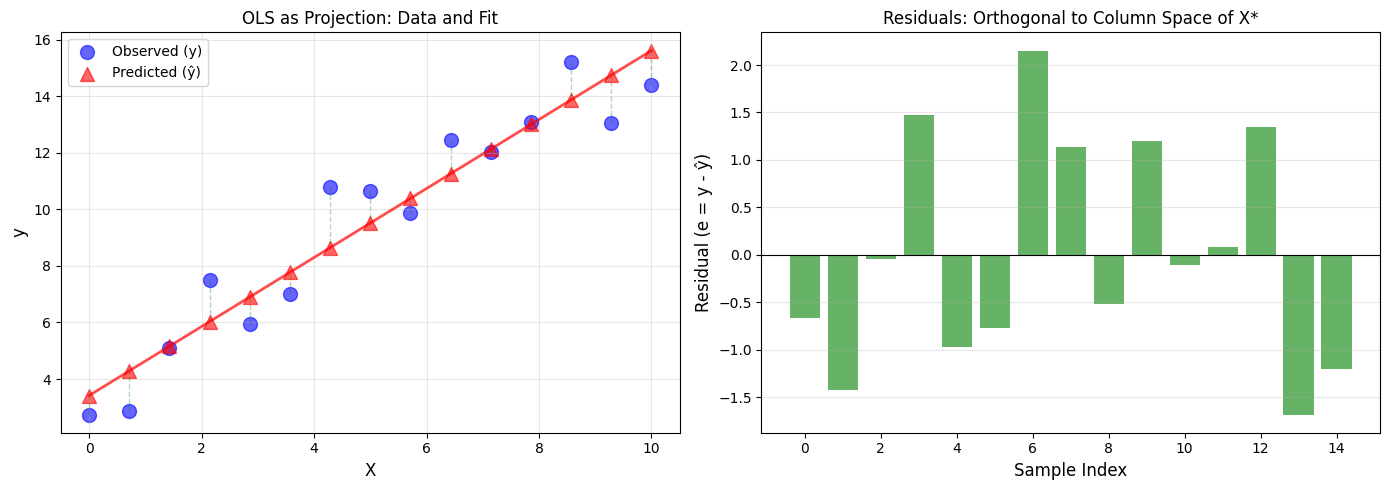


Vector Space Decomposition:
y = ŷ + e
||y||² = 1590.6268
||ŷ||² = 1570.7148
||e||² = 19.9119
||ŷ||² + ||e||² = 1590.6268
(Pythagorean theorem: ||y||² = ||ŷ||² + ||e||²)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Demonstrate OLS as projection for a simple 2D case
np.random.seed(42)

# Create sample data
n_samples = 15
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y = 2 + 1.5 * X.flatten() + np.random.normal(0, 1.5, n_samples)

# Add bias term
X_with_bias = np.hstack([np.ones((n_samples, 1)), X])

# OLS solution
from numpy.linalg import inv
w_hat = inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
y_pred = X_with_bias @ w_hat
residuals = y - y_pred

print("Linear Algebraic Interpretation of OLS:")
print("=" * 50)
print(f"\nDesign Matrix X* shape: {X_with_bias.shape}")
print(f"Observation vector y shape: {y.shape}")
print(f"Predicted vector ŷ shape: {y_pred.shape}")
print(f"Residual vector e shape: {residuals.shape}")

# Verify orthogonality: X*^T e should be approximately zero
orthogonality_check = X_with_bias.T @ residuals
print(f"\nOrthogonality Check (X*^T e):")
print(f"  {orthogonality_check}")
print(f"  (Should be close to zero, max value: {np.max(np.abs(orthogonality_check)):.2e})")

# Calculate projection matrix
P = X_with_bias @ inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T
print(f"\nProjection Matrix P shape: {P.shape}")
print(f"Predicted values ŷ = P y")
print(f"Verification: ||P y - ŷ|| = {np.linalg.norm(P @ y - y_pred):.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data and fit
ax1 = axes[0]
ax1.scatter(X, y, color='blue', label='Observed (y)', s=100, alpha=0.6)
ax1.scatter(X, y_pred, color='red', label='Predicted (ŷ)', s=100, alpha=0.6, marker='^')
for i in range(n_samples):
    ax1.plot([X[i, 0], X[i, 0]], [y[i], y_pred[i]], 'g--', alpha=0.3, linewidth=1)
ax1.plot(X, y_pred, color='red', linewidth=2, alpha=0.7)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('OLS as Projection: Data and Fit', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
ax2.bar(range(n_samples), residuals, color='green', alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Sample Index', fontsize=12)
ax2.set_ylabel('Residual (e = y - ŷ)', fontsize=12)
ax2.set_title('Residuals: Orthogonal to Column Space of X*', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Additional analysis: Decomposition of y
print(f"\nVector Space Decomposition:")
print(f"y = ŷ + e")
print(f"||y||² = {np.linalg.norm(y)**2:.4f}")
print(f"||ŷ||² = {np.linalg.norm(y_pred)**2:.4f}")
print(f"||e||² = {np.linalg.norm(residuals)**2:.4f}")
print(f"||ŷ||² + ||e||² = {np.linalg.norm(y_pred)**2 + np.linalg.norm(residuals)**2:.4f}")
print(f"(Pythagorean theorem: ||y||² = ||ŷ||² + ||e||²)")

## 6. Total Least Squares (TLS)

Total Least Squares (TLS) is a regression technique appropriate when there are errors in **both** the dependent and independent variables, not just the dependent variable as in OLS.

**Key Differences from OLS**:
- OLS minimizes vertical distances (errors in y only)
- TLS minimizes perpendicular distances (errors in both X and y)
- TLS is also known as Deming regression or orthogonal regression

**TLS Formulation**:
Instead of solving: minimize ||y - Xw||²

TLS solves: minimize ||ΔX||²_F + ||Δy||² subject to (X + ΔX)w = y + Δy

where ΔX and Δy are the perturbations to X and y respectively.

**Solution via SVD**:
The TLS solution can be obtained using Singular Value Decomposition (SVD) of the augmented matrix [X | y].

Total Least Squares (TLS) vs OLS Comparison:

OLS Solution:
  w₀ (intercept) = 1.6440
  w₁ (slope) = 1.5553

TLS Solution:
  w₀ (intercept) = 3.5442
  w₁ (slope) = 1.2674

True Parameters:
  w₀ (intercept) = 2.0000
  w₁ (slope) = 1.5000

Error Metrics:
  OLS - Sum of Squared Residuals: 24.1083
  TLS - Sum of Squared Residuals: 41.5634
  TLS - Sum of Squared Perpendicular Distances: 15.9468


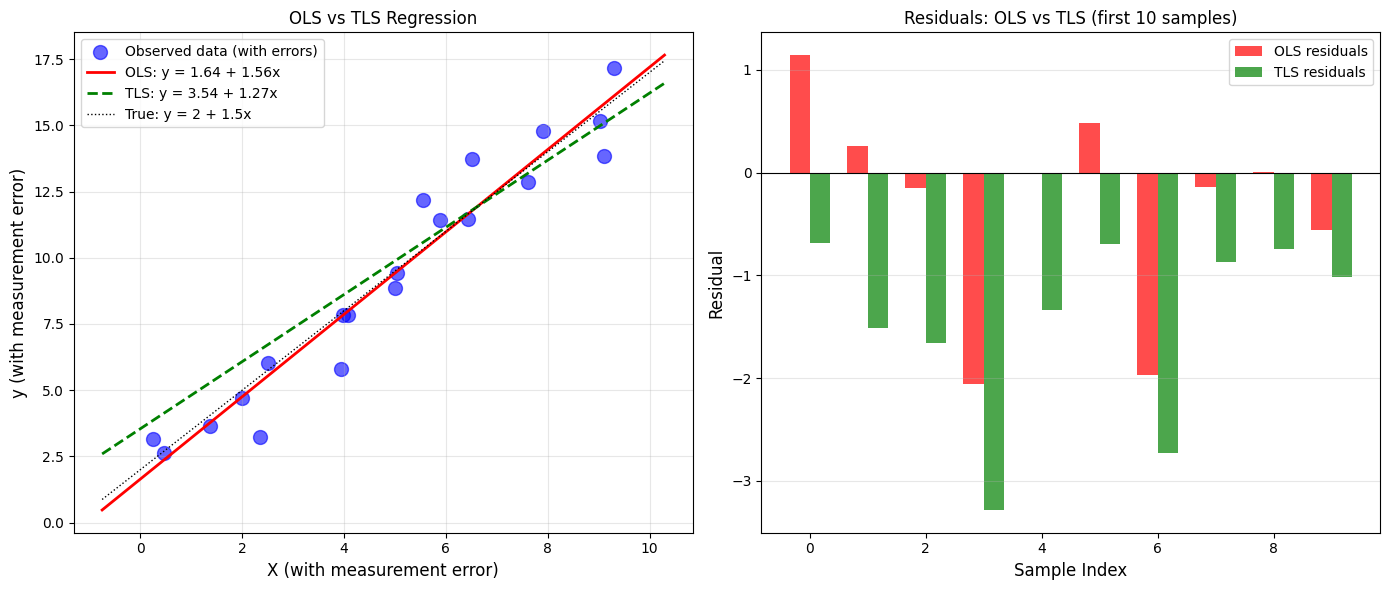

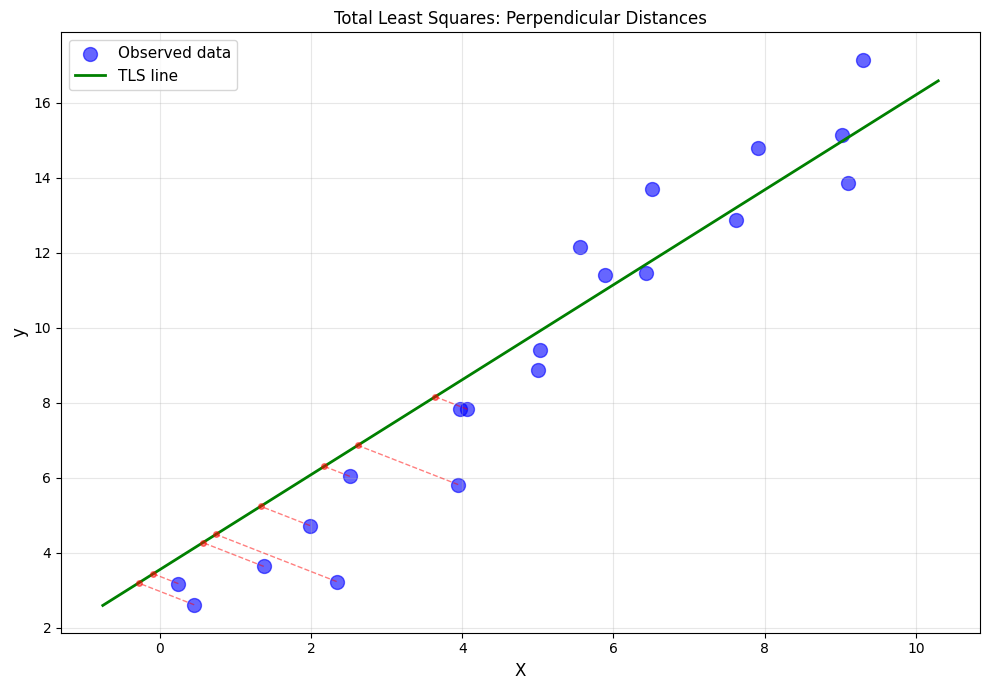

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Generate sample data with errors in both X and y
np.random.seed(42)
n_samples = 20

# True relationship: y = 2 + 1.5*x
x_true = np.linspace(0, 10, n_samples)
y_true = 2 + 1.5 * x_true

# Add errors to both X and y
X_noisy = x_true + np.random.normal(0, 0.5, n_samples)
y_noisy = y_true + np.random.normal(0, 0.8, n_samples)

# Prepare data matrices
X_matrix = X_noisy.reshape(-1, 1)
X_with_bias = np.hstack([np.ones((n_samples, 1)), X_matrix])

# Method 1: OLS solution
from numpy.linalg import inv
w_ols = inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y_noisy
y_pred_ols = X_with_bias @ w_ols

# Method 2: TLS solution using SVD
# Augment the matrix [X | y]
A_augmented = np.hstack([X_with_bias, y_noisy.reshape(-1, 1)])

# Perform SVD
U, s, Vt = svd(A_augmented, full_matrices=True)

# The TLS solution is related to the right singular vectors
# corresponding to the smallest singular value
V = Vt.T
v_last = V[:, -1]  # Last column (corresponds to smallest singular value)

# Extract TLS coefficients
# If v_last = [v1, v2, v3], then w_tls = -[v1, v2] / v3
w_tls = -v_last[:-1] / v_last[-1]
y_pred_tls = X_with_bias @ w_tls

print("Total Least Squares (TLS) vs OLS Comparison:")
print("=" * 50)
print(f"\nOLS Solution:")
print(f"  w₀ (intercept) = {w_ols[0]:.4f}")
print(f"  w₁ (slope) = {w_ols[1]:.4f}")

print(f"\nTLS Solution:")
print(f"  w₀ (intercept) = {w_tls[0]:.4f}")
print(f"  w₁ (slope) = {w_tls[1]:.4f}")

print(f"\nTrue Parameters:")
print(f"  w₀ (intercept) = 2.0000")
print(f"  w₁ (slope) = 1.5000")

# Calculate residuals
residuals_ols = y_noisy - y_pred_ols
residuals_tls = y_noisy - y_pred_tls

# For TLS, we also calculate the perpendicular distances
# Perpendicular distance from point (x_i, y_i) to line ax + by + c = 0
# is |ax_i + by_i + c| / sqrt(a^2 + b^2)
# Our line is: w_1*x - y + w_0 = 0
a_tls, b_tls, c_tls = w_tls[1], -1, w_tls[0]
perp_distances_tls = np.abs(a_tls * X_noisy + b_tls * y_noisy + c_tls) / np.sqrt(a_tls**2 + b_tls**2)

print(f"\nError Metrics:")
print(f"  OLS - Sum of Squared Residuals: {np.sum(residuals_ols**2):.4f}")
print(f"  TLS - Sum of Squared Residuals: {np.sum(residuals_tls**2):.4f}")
print(f"  TLS - Sum of Squared Perpendicular Distances: {np.sum(perp_distances_tls**2):.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: OLS vs TLS
ax1 = axes[0]
ax1.scatter(X_noisy, y_noisy, color='blue', label='Observed data (with errors)', s=100, alpha=0.6)

# Plot OLS line
x_line = np.linspace(X_noisy.min() - 1, X_noisy.max() + 1, 100)
X_line = np.hstack([np.ones((100, 1)), x_line.reshape(-1, 1)])
y_line_ols = X_line @ w_ols
y_line_tls = X_line @ w_tls

ax1.plot(x_line, y_line_ols, color='red', linewidth=2, label=f'OLS: y = {w_ols[0]:.2f} + {w_ols[1]:.2f}x')
ax1.plot(x_line, y_line_tls, color='green', linewidth=2, linestyle='--', label=f'TLS: y = {w_tls[0]:.2f} + {w_tls[1]:.2f}x')
ax1.plot(x_line, 2 + 1.5*x_line, color='black', linewidth=1, linestyle=':', label='True: y = 2 + 1.5x')

ax1.set_xlabel('X (with measurement error)', fontsize=12)
ax1.set_ylabel('y (with measurement error)', fontsize=12)
ax1.set_title('OLS vs TLS Regression', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals comparison
ax2 = axes[1]
x_pos = np.arange(min(10, n_samples))  # Show first 10 for clarity
width = 0.35

ax2.bar(x_pos - width/2, residuals_ols[:min(10, n_samples)], width, label='OLS residuals', alpha=0.7, color='red')
ax2.bar(x_pos + width/2, residuals_tls[:min(10, n_samples)], width, label='TLS residuals', alpha=0.7, color='green')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Sample Index', fontsize=12)
ax2.set_ylabel('Residual', fontsize=12)
ax2.set_title('Residuals: OLS vs TLS (first 10 samples)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Visualize perpendicular distances for TLS
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_noisy, y_noisy, color='blue', s=100, alpha=0.6, label='Observed data')
ax.plot(x_line, y_line_tls, color='green', linewidth=2, label='TLS line')

# Draw perpendicular lines from points to TLS line
for i in range(min(8, n_samples)):  # Show first 8 for clarity
    # Point on line closest to (X_noisy[i], y_noisy[i])
    # Using projection formula
    x_i, y_i = X_noisy[i], y_noisy[i]

    # Line equation: w_tls[1]*x - y + w_tls[0] = 0
    # Perpendicular from (x_i, y_i) to line
    a, b, c = w_tls[1], -1, w_tls[0]
    t = -(a*x_i + b*y_i + c) / (a**2 + b**2)
    x_proj = x_i + a*t
    y_proj = y_i + b*t

    ax.plot([x_i, x_proj], [y_i, y_proj], 'r--', alpha=0.5, linewidth=1)
    ax.plot(x_proj, y_proj, 'ro', markersize=4, alpha=0.5)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Total Least Squares: Perpendicular Distances', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Polynomial Regression

Polynomial regression is a form of linear regression in which the relationship between the independent variable x and the dependent variable y is modeled as an nth degree polynomial.

**General Form**:
$$y = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \cdots + w_n x^n + \epsilon$$

**Key Points**:
- Despite the name, polynomial regression is still a **linear regression** model because it is linear in the coefficients w
- The features are polynomial transformations of the original variable
- Higher degree polynomials can fit more complex relationships but risk overfitting
- Polynomial regression is useful when the relationship between variables is non-linear but can be approximated by a polynomial

**Advantages**:
- Can model non-linear relationships
- Still uses linear regression methods (OLS)
- Interpretable coefficients

**Disadvantages**:
- Risk of overfitting with high-degree polynomials
- Extrapolation beyond data range can be unreliable
- Requires careful selection of polynomial degree


Degree 1 Polynomial:
  Coefficients: [ 0.        -1.1763583]
  Intercept: 4.1511
  MSE: 15.7035
  R² Score: 0.4332

Degree 2 Polynomial:
  Coefficients: [ 0.         -1.1763583   0.34283136]
  Intercept: 1.1776
  MSE: 8.6384
  R² Score: 0.6882

Degree 3 Polynomial:
  Coefficients: [ 0.          0.66406783  0.34283136 -0.11794643]
  Intercept: 1.1776
  MSE: 3.0612
  R² Score: 0.8895

Degree 5 Polynomial:
  Coefficients: [ 0.00000000e+00  9.47662096e-01  3.52497431e-01 -1.68957995e-01
 -4.33972838e-04  1.76864632e-03]
  Intercept: 1.1525
  MSE: 3.0071
  R² Score: 0.8915


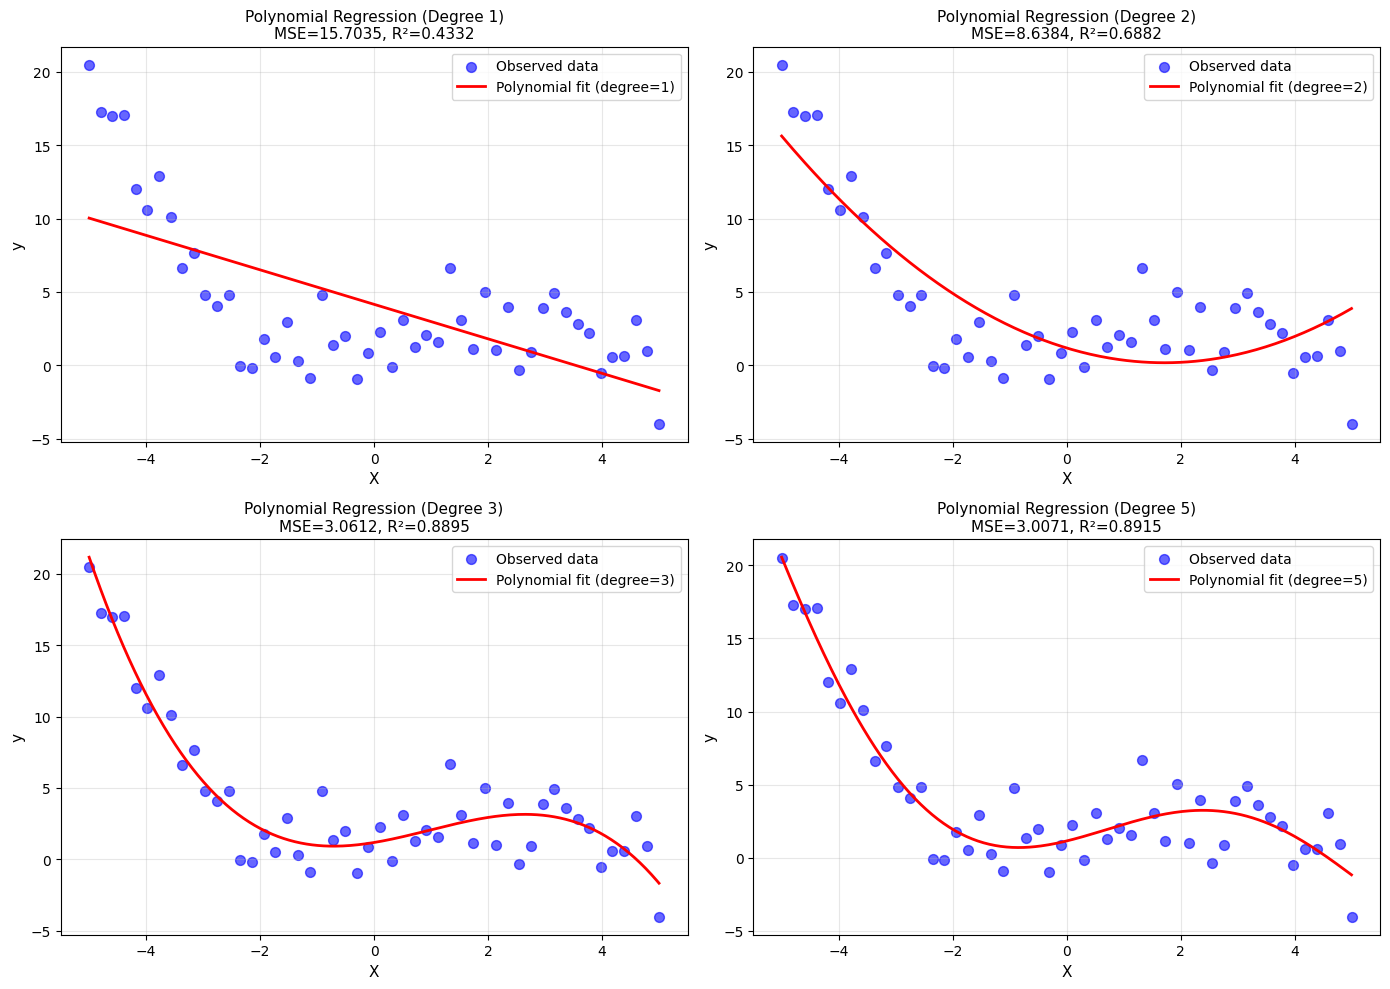


Model Comparison:
Degree 1: MSE = 15.7035, R² = 0.4332
Degree 2: MSE = 8.6384, R² = 0.6882
Degree 3: MSE = 3.0612, R² = 0.8895
Degree 5: MSE = 3.0071, R² = 0.8915


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate non-linear sample data
np.random.seed(42)
n_samples = 50
X = np.linspace(-5, 5, n_samples).reshape(-1, 1)
y = 2 + 0.5*X.flatten() + 0.3*X.flatten()**2 - 0.1*X.flatten()**3 + np.random.normal(0, 2, n_samples)

# Create polynomial features for different degrees
degrees = [1, 2, 3, 5]
models = {}
predictions = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Generate smooth curve for plotting
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)
    X_smooth_poly = poly_features.transform(X_smooth)

    # Fit model
    model = LinearRegression()
    model.fit(X_poly, y)

    # Make predictions
    y_pred = model.predict(X_poly)
    y_smooth = model.predict(X_smooth_poly)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    models[degree] = model
    predictions[degree] = y_pred

    # Plot
    ax = axes[idx]
    ax.scatter(X, y, color='blue', label='Observed data', s=50, alpha=0.6)
    ax.plot(X_smooth, y_smooth, color='red', linewidth=2, label=f'Polynomial fit (degree={degree})')
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'Polynomial Regression (Degree {degree})\nMSE={mse:.4f}, R²={r2:.4f}', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Print coefficients
    print(f"\nDegree {degree} Polynomial:")
    print(f"  Coefficients: {model.coef_}")
    print(f"  Intercept: {model.intercept_:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R² Score: {r2:.4f}")

plt.tight_layout()
plt.show()

# Comparison of all models
print("\n" + "="*60)
print("Model Comparison:")
print("="*60)
for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)
    y_pred = models[degree].predict(X_poly)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    print(f"Degree {degree}: MSE = {mse:.4f}, R² = {r2:.4f}")

## 8. Logarithmic Regression

Logarithmic regression is used when the relationship between variables follows a logarithmic pattern. It models the relationship where the rate of change decreases as the independent variable increases.

**General Form**:
$$y = w_0 + w_1 \log(x) + \epsilon$$

or more generally:
$$y = w_0 + w_1 \log(x) + w_2 \log(x)^2 + \cdots + w_n \log(x)^n + \epsilon$$

**Key Points**:
- The independent variable x must be positive (x > 0)
- Logarithmic regression is linear in the log-transformed variable
- Useful for modeling diminishing returns or saturation effects
- Common in economics, biology, and physics

**When to Use Logarithmic Regression**:
- Data shows a rapid increase followed by leveling off
- Relationship between variables is non-linear but follows logarithmic pattern
- Examples: learning curves, dose-response relationships, diminishing returns

**Advantages**:
- Simple to implement and interpret
- Reduces the impact of large values
- Can model saturation effects

**Disadvantages**:
- Requires positive x values
- May not fit all non-linear relationships
- Extrapolation can be unreliable

Logarithmic Regression Results:
Model: y = 3.0659 + 1.9077 * log(x)
MSE: 0.0722
R² Score: 0.9651

Quadratic Logarithmic Regression:
Model: y = 3.0882 + 1.7948 * log(x) + 0.0534 * log(x)²
MSE: 0.0711
R² Score: 0.9656


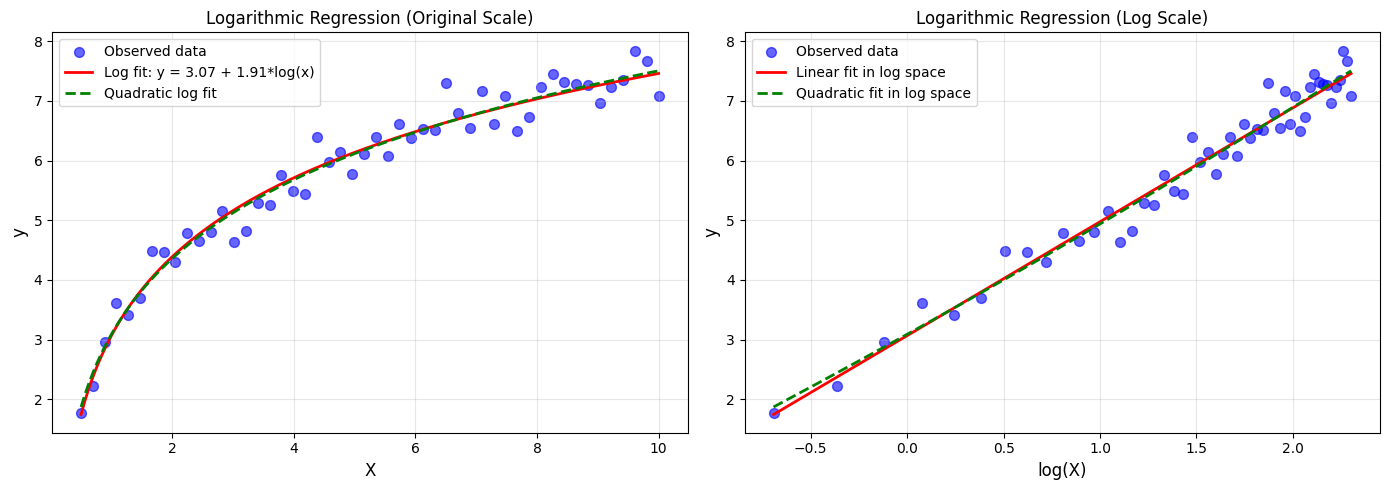

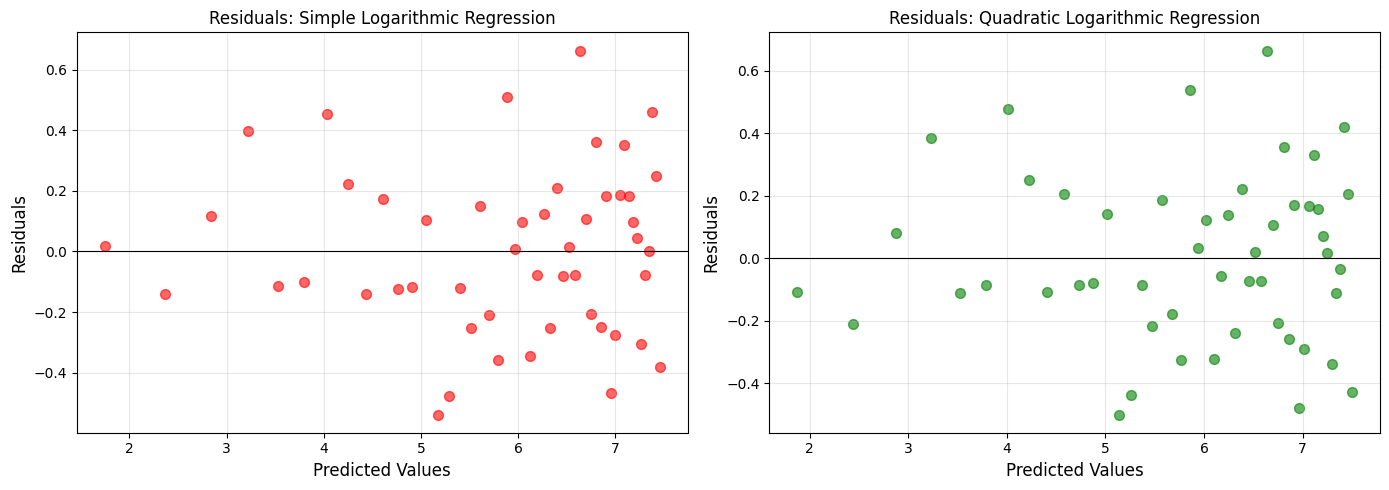


Practical Example: Learning Curve

Learning Curve Model:
Accuracy = 70.92 + 7.37 * log(hours)
R² Score: 0.6355


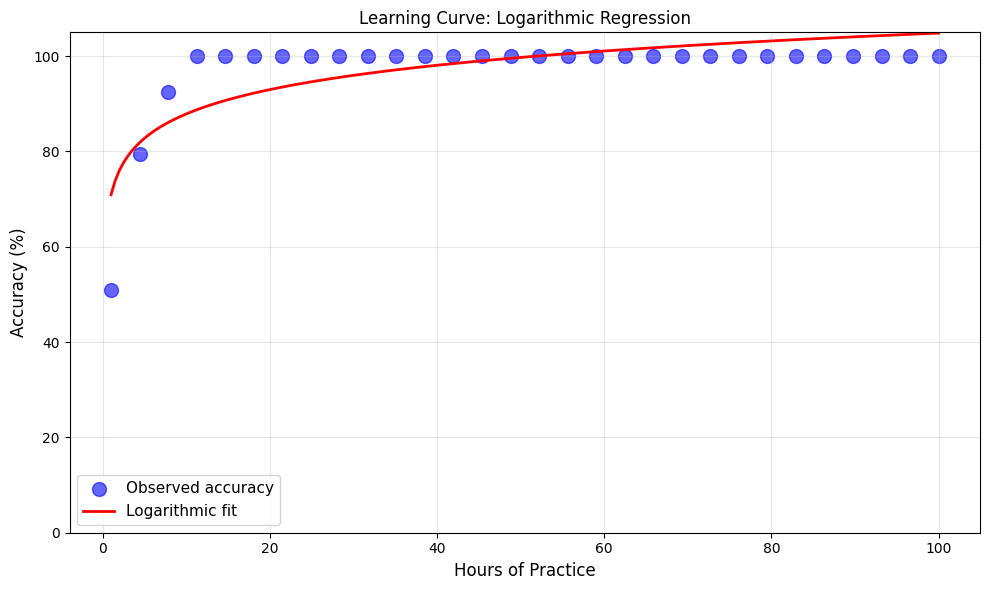

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate logarithmic sample data
np.random.seed(42)
n_samples = 50
X = np.linspace(0.5, 10, n_samples).reshape(-1, 1)
# True relationship: y = 3 + 2*log(x)
y = 3 + 2*np.log(X.flatten()) + np.random.normal(0, 0.3, n_samples)

# Method 1: Simple Logarithmic Regression
X_log = np.log(X)
model_log = LinearRegression()
model_log.fit(X_log, y)
y_pred_log = model_log.predict(X_log)

# Calculate metrics
mse_log = mean_squared_error(y, y_pred_log)
r2_log = r2_score(y, y_pred_log)

print("Logarithmic Regression Results:")
print("="*50)
print(f"Model: y = {model_log.intercept_:.4f} + {model_log.coef_[0]:.4f} * log(x)")
print(f"MSE: {mse_log:.4f}")
print(f"R² Score: {r2_log:.4f}")

# For comparison: fit a polynomial to log-transformed data
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2)
X_log_poly = poly_features.fit_transform(X_log)
model_log_poly = LinearRegression()
model_log_poly.fit(X_log_poly, y)
y_pred_log_poly = model_log_poly.predict(X_log_poly)

mse_log_poly = mean_squared_error(y, y_pred_log_poly)
r2_log_poly = r2_score(y, y_pred_log_poly)

print(f"\nQuadratic Logarithmic Regression:")
print(f"Model: y = {model_log_poly.intercept_:.4f} + {model_log_poly.coef_[1]:.4f} * log(x) + {model_log_poly.coef_[2]:.4f} * log(x)²")
print(f"MSE: {mse_log_poly:.4f}")
print(f"R² Score: {r2_log_poly:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generate smooth curve for plotting
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_smooth_log = np.log(X_smooth)

# Plot 1: Original scale
ax1 = axes[0]
ax1.scatter(X, y, color='blue', label='Observed data', s=50, alpha=0.6)

y_smooth_log = model_log.predict(X_smooth_log)
y_smooth_log_poly = model_log_poly.predict(poly_features.transform(X_smooth_log))

ax1.plot(X_smooth, y_smooth_log, color='red', linewidth=2, label=f'Log fit: y = {model_log.intercept_:.2f} + {model_log.coef_[0]:.2f}*log(x)')
ax1.plot(X_smooth, y_smooth_log_poly, color='green', linewidth=2, linestyle='--', label='Quadratic log fit')
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Logarithmic Regression (Original Scale)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Log scale (X-axis)
ax2 = axes[1]
ax2.scatter(X_log, y, color='blue', label='Observed data', s=50, alpha=0.6)
ax2.plot(X_smooth_log, y_smooth_log, color='red', linewidth=2, label=f'Linear fit in log space')
ax2.plot(X_smooth_log, y_smooth_log_poly, color='green', linewidth=2, linestyle='--', label='Quadratic fit in log space')
ax2.set_xlabel('log(X)', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Logarithmic Regression (Log Scale)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals for simple log regression
residuals_log = y - y_pred_log
ax1 = axes[0]
ax1.scatter(y_pred_log, residuals_log, color='red', s=50, alpha=0.6)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title('Residuals: Simple Logarithmic Regression', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals for quadratic log regression
residuals_log_poly = y - y_pred_log_poly
ax2 = axes[1]
ax2.scatter(y_pred_log_poly, residuals_log_poly, color='green', s=50, alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Predicted Values', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residuals: Quadratic Logarithmic Regression', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Practical example: Learning curve
print("\n" + "="*60)
print("Practical Example: Learning Curve")
print("="*60)

# Simulate learning curve data (hours of practice vs accuracy)
np.random.seed(42)
hours = np.linspace(1, 100, 30).reshape(-1, 1)
# Accuracy increases logarithmically with practice
accuracy = 50 + 20*np.log(hours.flatten()) + np.random.normal(0, 2, 30)
accuracy = np.clip(accuracy, 0, 100)  # Clip to [0, 100]

# Fit logarithmic model
X_hours_log = np.log(hours)
model_learning = LinearRegression()
model_learning.fit(X_hours_log, accuracy)
accuracy_pred = model_learning.predict(X_hours_log)

r2_learning = r2_score(accuracy, accuracy_pred)

print(f"\nLearning Curve Model:")
print(f"Accuracy = {model_learning.intercept_:.2f} + {model_learning.coef_[0]:.2f} * log(hours)")
print(f"R² Score: {r2_learning:.4f}")

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.scatter(hours, accuracy, color='blue', label='Observed accuracy', s=100, alpha=0.6)

hours_smooth = np.linspace(hours.min(), hours.max(), 200).reshape(-1, 1)
accuracy_smooth = model_learning.predict(np.log(hours_smooth))
plt.plot(hours_smooth, accuracy_smooth, color='red', linewidth=2, label='Logarithmic fit')

plt.xlabel('Hours of Practice', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Learning Curve: Logarithmic Regression', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 105])
plt.tight_layout()
plt.show()

## Summary and Comparison

| Regression Type | Equation | Use Case | Advantages | Disadvantages |
|---|---|---|---|---|
| **Linear** | y = w₀ + w₁x | Simple relationships | Easy to interpret, fast | May not fit complex patterns |
| **Multiple Linear** | y = w₀ + w₁x₁ + w₂x₂ + ... | Multiple predictors | Handles multiple features | Assumes linear relationships |
| **Polynomial** | y = w₀ + w₁x + w₂x² + ... | Non-linear patterns | Flexible, still linear in coefficients | Risk of overfitting |
| **Logarithmic** | y = w₀ + w₁log(x) | Diminishing returns | Simple, interpretable | Requires x > 0, limited flexibility |
| **OLS** | Normal equation solution | Standard regression | Analytical solution, optimal | Assumes specific error distribution |
| **TLS** | SVD-based solution | Errors in X and y | Accounts for measurement error | More complex, higher computation |

### Key Takeaways

1. **Regression** is used to model relationships between variables and make predictions
2. **Simple Linear Regression** handles one independent variable
3. **Multiple Linear Regression** extends to multiple independent variables
4. **OLS** is the standard method that minimizes squared vertical distances
5. **Linear Algebraic Interpretation** shows OLS as projection onto column space
6. **Total Least Squares** is appropriate when both variables have measurement errors
7. **Polynomial Regression** can model non-linear relationships while remaining linear in coefficients
8. **Logarithmic Regression** is useful for modeling diminishing returns and saturation effects
9. **Model Selection** should be based on data characteristics, domain knowledge, and validation metrics